In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# Distill a complete response, not a three-logit vector

Day 26 · Chapter 15 · extension · CPU reference. Chapter 9 sections 9.12–9.13 supply the supervised-objective bridge.

A teacher prints `STEP 2 ANS 0 EOS`. What is the student taught: a final answer, a distribution over vocabulary, or the complete sequence? Predict whether a correct final answer proves the printed step is correct—and whether a correct printed step proves faithful internal reasoning.

We study an original symbolic sum/parity task with actual tiny autoregressive teacher/student models, not pretrained English reasoning. Every STEP/ANS/digit/EOS is sampled from the full 15-token vocabulary; syntax is never forced. The three-seed historical campaign is immutable. A fresh fixed-seed fit below checks the lesson mechanisms; it is not a new recipe search.

In [2]:
from pathlib import Path
import sys, json, hashlib
from copy import deepcopy
from collections import Counter
root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"src/dongxi_llms").is_dir())
if str(root/"src") not in sys.path: sys.path.insert(0,str(root/"src"))
import torch, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from dongxi_llms.response_distillation_lab import (ANS,DIGIT,EOS,STEP,TEACHER_UPDATES,STUDENT_UPDATES,
    adapt_teacher,attach_digest,batch_examples,decode,fit_model,generate,grade,make_model,
    prefix,select,state_digest,token_loss_sum,truth,validate_contract,validate_fixture)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize":(9,4),"font.size":10,"font.family":"DejaVu Sans",
                     "axes.spines.top":False,"axes.spines.right":False})
fixture=json.loads((root/"fixtures/response-distillation/items.json").read_text())
directory=root/"experiments/reports/2026-10-04-response-distillation"
raw=(directory/"results.json").read_bytes()
assert hashlib.sha256(raw).hexdigest()=="8eea7cb206d449d0d3f4297248621463df8452980768792bf155ea869f2c2aee"
measured=json.loads(raw);contract=json.loads((directory/"contract.json").read_text())
validate_fixture(fixture);validate_contract(contract,fixture)
# Measurement sources must still match their recorded bytes.
for path,digest in measured["source_input_sha256"].items():
    source=Path(path);source=source if source.is_absolute() else root/source
    assert hashlib.sha256(source.read_bytes()).hexdigest()==digest,source
items=fixture["items"];runs=measured["runs"]
labels=["original-student","teacher","complete-response","answer-only"]
colors=["#858585","#326b9e","#cd7846","#518364"]
print("Original CPU panel:",len(runs),"campaigns; source identities match.")


Original CPU panel: 3 campaigns; source identities match.


### Prediction

## 1. The supervision boundary

Exercise: which logit predicts the first STEP? Where does EOS receive loss? Does masking the prompt remove the prompt’s influence on the answer?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


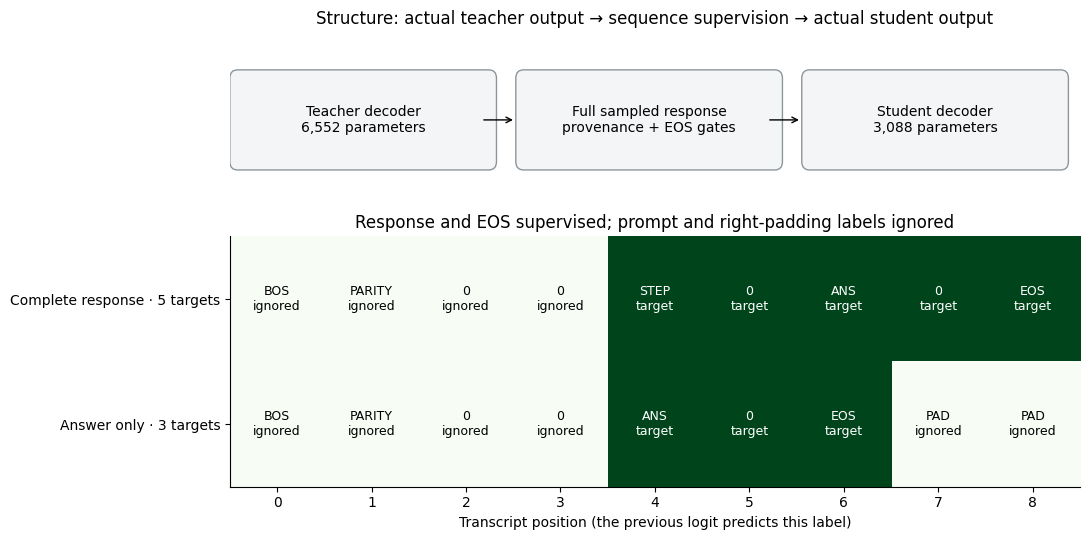

Direct prompt-prediction logits ignored; final prompt logit predicts STEP; EOS receives loss.


In [3]:
chosen=runs[0]["selection"]["full"][0]
short=runs[0]["selection"]["answer_only"][0]
batch=batch_examples([chosen,short])
fig,(top,bottom)=plt.subplots(2,1,figsize=(11,5.5),gridspec_kw={"height_ratios":[1,1.5]})
top.set(xlim=(0,11),ylim=(0,2));top.axis("off")
boxes=[(.1,"Teacher decoder\n6,552 parameters"),(3.8,"Full sampled response\nprovenance + EOS gates"),(7.5,"Student decoder\n3,088 parameters")]
for x,text in boxes:
    top.add_patch(FancyBboxPatch((x,.45),3.25,1.0,boxstyle="round,pad=.1",facecolor="#f3f5f6",edgecolor="#8d969c"))
    top.text(x+1.625,.95,text,ha="center",va="center")
for x in (3.45,7.15):top.annotate("",xy=(x+.25,.95),xytext=(x-.2,.95),arrowprops={"arrowstyle":"->"})
top.set_title("Structure: actual teacher output → sequence supervision → actual student output")
mask=(batch["labels"]!=-100).numpy().astype(float)
bottom.imshow(mask,cmap="Greens",vmin=0,vmax=1,aspect="auto")
for r,example in enumerate((chosen,short)):
    full=example["prompt_ids"]+example["response_ids"]
    for t in range(mask.shape[1]):
        word=decode([full[t]]) if t<len(full) else "PAD"
        bottom.text(t,r,word+"\n"+("target" if mask[r,t] else "ignored"),ha="center",va="center",fontsize=9,color="white" if mask[r,t] else "black")
bottom.set(yticks=[0,1],yticklabels=["Complete response · 5 targets","Answer only · 3 targets"],
           xticks=range(mask.shape[1]),xlabel="Transcript position (the previous logit predicts this label)",
           title="Response and EOS supervised; prompt and right-padding labels ignored")
plt.tight_layout();plt.show()
probe=make_model(26011);logits=probe(batch["input_ids"]);logits.retain_grad()
loss,count=token_loss_sum(logits,batch["labels"]);(loss/count).backward()
assert count==8 and float(logits.grad[0,:3].abs().sum())==0.
assert float(logits.grad[0,3].abs().sum())>0 and float(logits.grad[0,7].abs().sum())>0
print("Direct prompt-prediction logits ignored; final prompt logit predicts STEP; EOS receives loss.")


### Reference explanation

Reference: the final prompt position predicts STEP after one causal shift. EOS is a response target, not padding. The earlier prompt prediction logits have no direct loss, but their representations can receive gradients through later response computations. The structural map below is a schematic, not measured inference latency.


Saved reference previews are fixed results from fresh CPU execution. Running the plot cells regenerates their figures from the current tensors or source-bound measured panel.

![Response provenance and supervision masks](../figures/chapter-15/day-26-03_response_level_distillation-01.png)

### Prediction

## 2. A fresh teacher → response → student replay

Exercise: would picking the teacher’s most correct response be the same experiment as taking the first well-formed response?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [4]:
train=[i for i in items if i["split"]=="train"];seed=26011
teacher=make_model(seed+1000,teacher=True)
gold=[{"item_id":i["id"],"prompt_ids":prefix(i),
       "response_ids":[STEP,DIGIT+truth(i)[0],ANS,DIGIT+truth(i)[1],EOS]} for i in train]
teacher_fit=fit_model(teacher,gold,updates=TEACHER_UPDATES,lr=.01)
assert teacher_fit["final_state_sha256"]==runs[0]["teacher_fit"]["final_state_sha256"]
responses=[generate(teacher,i,contract,campaign=seed,phase="teacher-data",ordinal=o)
           for i in train for o in range(8)]
selection=adapt_teacher(responses,items,contract,state_digest(teacher))
assert not selection["missing_train_ids"]
assert [r["token_ids"] for r in responses]==[r["token_ids"] for r in runs[0]["teacher_records"]]
initial=make_model(seed)
fresh_students={}
for arm,examples in (("complete-response",selection["full"]),("answer-only",selection["answer_only"])):
    student=deepcopy(initial)
    fit=fit_model(student,examples,updates=STUDENT_UPDATES,lr=.015)
    assert fit["final_state_sha256"]==runs[0]["student_fits"][arm]["final_state_sha256"]
    assert fit["initial_state_sha256"]==runs[0]["student_fits"][arm]["initial_state_sha256"]
    fresh_students[arm]=student
    print(arm,"targets per update:",fit["supervised_targets_per_update"],
          "first loss:",round(fit["history"][0]["loss"],6),"last:",round(fit["history"][-1]["loss"],6))
# Both final AND printed step are generated, not copied from a checker.
item=items[6]
for arm,student in fresh_students.items():
    fresh=generate(student,item,contract,campaign=seed,phase="evaluation-"+arm,ordinal=0)
    stored=next(e for e in runs[0]["evaluations"] if e["label"]==arm)["pools"][6]["responses"][0]
    assert fresh["token_ids"]==stored["token_ids"]
    print(arm,item["id"],fresh["raw_response"],grade(item,fresh))


complete-response targets per update: 30 first loss: 2.696378 last: 0.001525
answer-only targets per update: 18 first loss: 2.653267 last: 0.00245
complete-response distill-test-20 STEP 2 ANS 0 EOS {'sample_id': 'e59329741894c6b83b89b71bf0dc46b581ea60ae3f56b2f007086e94276356af', 'item_id': 'distill-test-20', 'source_group': 'distill-parity-2-0', 'slice': 'heldout-source', 'answer_correct': True, 'printed_step_valid': True, 'format_valid': True, 'natural_EOS': True, 'joint_trace_correct': True, 'wrong_step_right_answer': False, 'valid_step_wrong_answer': False, 'step_status': 'valid'}
answer-only distill-test-20 ANS 0 EOS {'sample_id': '421143859883238426dd193bdc97da9899bc9398a33dfaf2743385fce59a4cf5', 'item_id': 'distill-test-20', 'source_group': 'distill-parity-2-0', 'slice': 'heldout-source', 'answer_correct': True, 'printed_step_valid': None, 'format_valid': True, 'natural_EOS': True, 'joint_trace_correct': False, 'wrong_step_right_answer': False, 'valid_step_wrong_answer': False, '

### Reference explanation

Reference: no. Gold-dependent selection changes the teacher-data distribution. The adapter below selects first format-eligible fulltrace, without checking arithmetic correctness. If any source has no eligible record, both student arms are blocked; no gold repair. The historical run happened to select 18 correct traces across all three seeds. Wrong well-formed responses remain eligible by contract, checked later with an explicitly authored perturbation.

The fresh fixed recipe reproduces the stored numeric checkpoints and candidate IDs exactly in this CPU environment. This is a same-environment replay, not a cross-device reproducibility or deployment-speed guarantee.


### Prediction

## 3. Falling NLL is not the entire result

Predict: should a near-zero training NLL imply valid intermediate totals on new operands? Read all three campaigns rather than choosing the best one.

![Actual teacher and student learning curves](../figures/chapter-15/day-26-03_response_level_distillation-02.png)

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


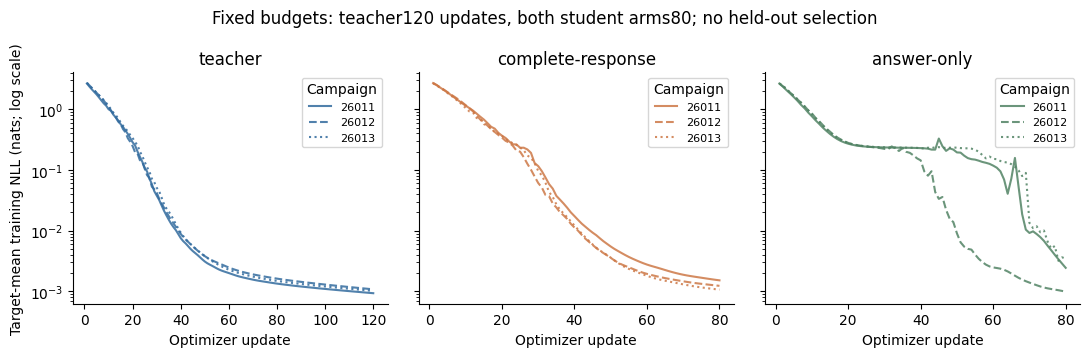

In [5]:
fig,axes=plt.subplots(1,3,figsize=(11,3.6),sharey=True)
for ax,arm,color in zip(axes,["teacher","complete-response","answer-only"],colors[1:]):
    for run in runs:
        fit=run["teacher_fit"] if arm=="teacher" else run["student_fits"][arm]
        ax.plot([h["update"] for h in fit["history"]],[h["loss"] for h in fit["history"]],
                color=color,alpha=.85,linestyle=["-","--",":"][run["campaign"]-26011],label=str(run["campaign"]))
    ax.set(title=arm,xlabel="Optimizer update",yscale="log");ax.legend(title="Campaign",fontsize=8)
axes[0].set_ylabel("Target-mean training NLL (nats; log scale)")
fig.suptitle("Fixed budgets: teacher120 updates, both student arms80; no held-out selection")
plt.tight_layout();plt.show()


### Reference explanation

Reference: these curves establish that the fixed train responses were learned. They cannot alone establish new-source arithmetic, unseen instruction behavior, causal rationale faithfulness, or a general advantage of longer supervision.


### Prediction

## 4. Final answer versus complete printed trace

Exercise: why is joint-trace success zero for the answer-only arm even when its final answers are correct? Should that make its answer-only contract a failure?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


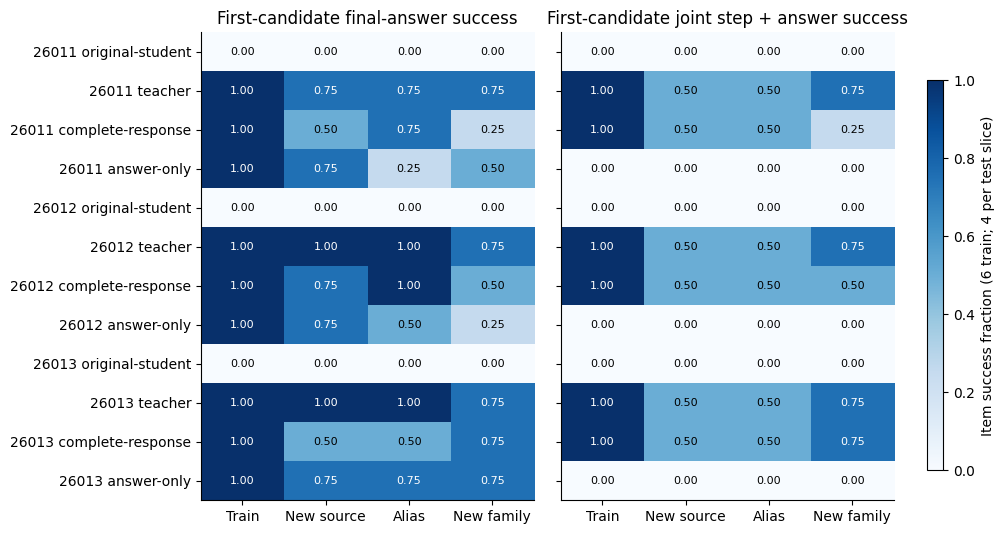

In [6]:
slices=["train","heldout-source","heldout-template","heldout-family"]
fig,axes=plt.subplots(1,2,figsize=(11,6),sharey=True)
rows=[(run,arm) for run in runs for arm in labels]
for ax,key,title in zip(axes,["answer_success","joint_trace_success"],
                       ["First-candidate final-answer success","First-candidate joint step + answer success"]):
    values=np.array([[next(s[key] for s in next(e for e in run["evaluations"] if e["label"]==arm)["summary"]
                         if s["slice"]==slice_name and s["method"]=="first") for slice_name in slices] for run,arm in rows])
    image=ax.imshow(values,vmin=0,vmax=1,cmap="Blues",aspect="auto")
    for y,x in np.ndindex(values.shape):ax.text(x,y,f"{values[y,x]:.2f}",ha="center",va="center",
                                              color="white" if values[y,x]>.6 else "black",fontsize=8)
    ax.set(xticks=range(4),xticklabels=["Train","New source","Alias","New family"],title=title,
           yticks=range(len(rows)),yticklabels=[str(r["campaign"])+" "+a for r,a in rows])
fig.subplots_adjust(left=.23,right=.86,bottom=.1,top=.88,wspace=.08)
color_axis=fig.add_axes([.89,.15,.015,.65])
fig.colorbar(image,cax=color_axis,label="Item success fraction (6 train; 4 per test slice)")
plt.show()


### Reference explanation

Reference: no printed step is provided under its trained short-response contract. The missing trace is not secretly a correct step or an observed wrong step. Use final-answer success for the common task comparison and keep joint-trace success as a separate requirement.

![Answer and trace outcomes on train and held-out slices](../figures/chapter-15/day-26-03_response_level_distillation-03.png)

The held-out slices each contain only four items. Alias siblings share source groups with the source-heldout items, so these are diagnostic slices, not independent replications. Unseen-family labels have a 3:1 class imbalance. Small positive or negative changes are not broad reasoning evidence.


### Prediction

## 5. A printed step and an answer are different observations

Predict which truth-table cells real generated responses occupy. Separately, the four authored probes intentionally populate all cells; they are not actual model samples or replacement training data.

![Actual generated step-answer truth tables](../figures/chapter-15/day-26-03_response_level_distillation-04.png)

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


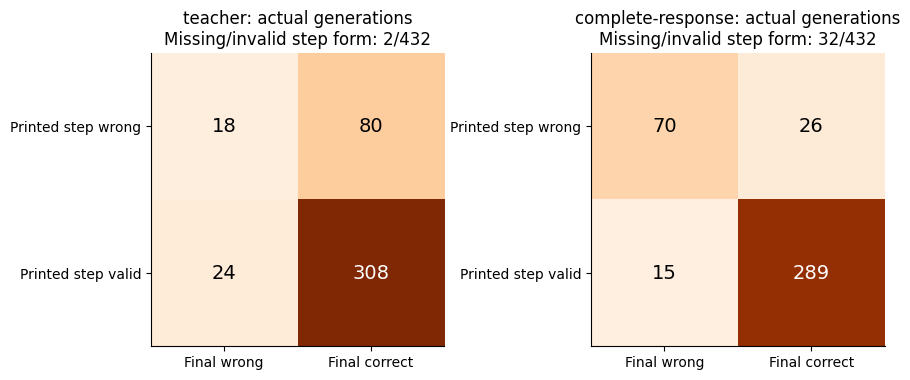

Separate authored semantic probes:
both-valid printed step: True final: True
wrong-step-right-answer printed step: False final: True
valid-step-wrong-answer printed step: True final: False
both-wrong printed step: False final: False


In [7]:
fig,axes=plt.subplots(1,2,figsize=(9,4))
for ax,arm in zip(axes,["teacher","complete-response"]):
    matrix=np.zeros((2,2),dtype=int);missing=0
    for run in runs:
        ev=next(e for e in run["evaluations"] if e["label"]==arm)
        for pool in ev["pools"]:
            for g in pool["grades"]:
                if g["printed_step_valid"] is None:missing+=1
                else:matrix[int(g["printed_step_valid"]),int(g["answer_correct"])]+=1
    ax.imshow(matrix,cmap="Oranges",vmin=0,vmax=310)
    for y,x in np.ndindex(matrix.shape):ax.text(x,y,str(matrix[y,x]),ha="center",va="center",fontsize=14,color="white" if matrix[y,x]>180 else "black")
    ax.set(xticks=[0,1],xticklabels=["Final wrong","Final correct"],yticks=[0,1],yticklabels=["Printed step wrong","Printed step valid"],
           title=f"{arm}: actual generations\nMissing/invalid step form: {missing}/432")
plt.tight_layout();plt.show()
print("Separate authored semantic probes:")
for p in fixture["authored_probes"]:
    print(p["id"],"printed step:",p["printed_step_valid"],"final:",p["answer_correct"])


### Reference explanation

Reference: the teacher produces 80 wrong-step/right-answer and 24 valid-step/wrong-answer generations; the complete-response student produces 26 and15. These are actual held-out/train evaluation outputs. A verified printed total is evidence about its text only. It does not prove that total caused the answer or corresponds to an internal reasoning state.


### Prediction

## 6. Selection does not remove the need to grade steps

Exercise: can majority-final voting improve final accuracy while choosing a wrong-step/right-answer response? Is mean model log-probability a quality judge?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


26011 complete-response held-out selector rates [0.5, 0.5833333333333334, 0.5833333333333334] oracle availability 0.6666666666666666
26012 complete-response held-out selector rates [0.75, 0.8333333333333334, 0.8333333333333334] oracle availability 0.9166666666666666
26013 complete-response held-out selector rates [0.5833333333333334, 0.5833333333333334, 0.5833333333333334] oracle availability 0.5833333333333334
26011 answer-only held-out selector rates [0.5, 0.6666666666666666, 0.6666666666666666] oracle availability 0.6666666666666666
26012 answer-only held-out selector rates [0.5, 0.4166666666666667, 0.5833333333333334] oracle availability 0.6666666666666666
26013 answer-only held-out selector rates [0.75, 0.75, 0.75] oracle availability 0.75


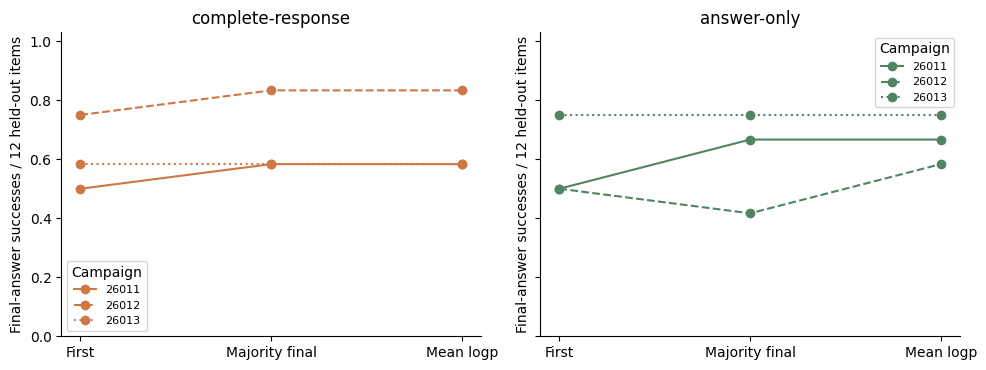

In [8]:
fig,axes=plt.subplots(1,2,figsize=(10,3.8),sharey=True)
methods=["first","majority","mean_logp"]
for ax,arm,color in zip(axes,["complete-response","answer-only"],colors[2:]):
    for run in runs:
        ev=next(e for e in run["evaluations"] if e["label"]==arm)
        held=[p for p in ev["pools"] if p["slice"]!="train"]
        values=[sum(p["decisions"][m]["answer_success"] for p in held)/len(held) for m in range(3)]
        ax.plot(range(3),values,marker="o",color=color,linestyle=["-","--",":"][run["campaign"]-26011],label=str(run["campaign"]))
        oracle=sum(any(g["answer_correct"] for g in p["grades"]) for p in held)/len(held)
        print(run["campaign"],arm,"held-out selector rates",values,"oracle availability",oracle)
    ax.set(xticks=range(3),xticklabels=["First","Majority final","Mean logp"],ylim=(0,1.03),title=arm,
           ylabel="Final-answer successes / 12 held-out items");ax.legend(title="Campaign",fontsize=8)
plt.tight_layout();plt.show()


### Reference explanation

Reference: both selectors see output IDs and eligibility, not gold. Majority counts final labels; likelihood ranks the model’s own confidence, not preference or rationale truth. Oracle availability is evaluator-only. All selectors reuse the same eight attempts, including failures and costs.

![Fixed-pool selector comparison](../figures/chapter-15/day-26-03_response_level_distillation-05.png)


### Prediction

## 7. Costs belong to both sides of distillation

Exercise: if the student is smaller, can we infer that collecting its training data was free—or that it will be faster in deployment?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


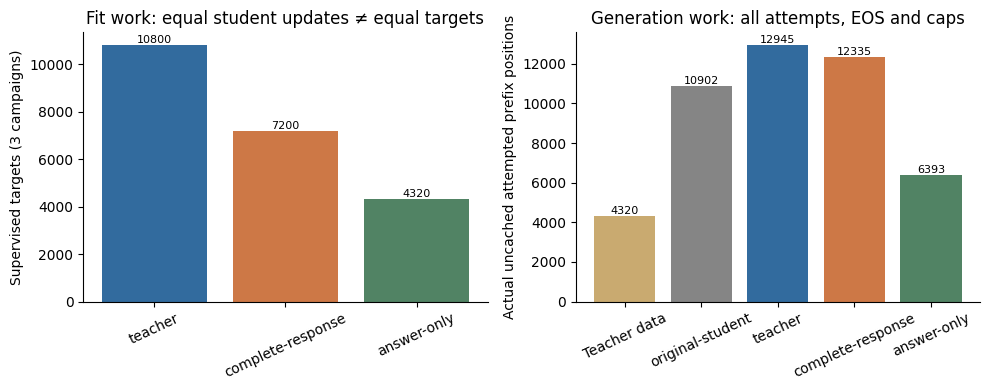

Campaign wall: 19.475 s; lifetime peak RSS: 754740 KiB
MemAvailable before/after observations: {'before': 123671328, 'after': 123619988} ; not a monitored minimum
Per-attempt timers exclude state hashing/journal serialization; complete campaign wall includes that overhead.


In [9]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
fit_arms=["teacher","complete-response","answer-only"]
targets=[sum((r["teacher_fit"] if a=="teacher" else r["student_fits"][a])["supervised_target_presentations"] for r in runs) for a in fit_arms]
axes[0].bar(fit_arms,targets,color=colors[1:]);axes[0].set(ylabel="Supervised targets (3 campaigns)",title="Fit work: equal student updates ≠ equal targets")
names=["Teacher data"]+labels
positions=[sum(r["teacher_data_cost"]["attempted_forward_positions"] for r in runs)]+[
    sum(next(e for e in r["evaluations"] if e["label"]==a)["cost"]["attempted_forward_positions"] for r in runs) for a in labels]
axes[1].bar(names,positions,color=["#c9aa70"]+colors);axes[1].set(ylabel="Actual uncached attempted prefix positions",title="Generation work: all attempts, EOS and caps")
for ax in axes:
    ax.tick_params(axis="x",labelrotation=25)
    for bar in ax.patches:ax.text(bar.get_x()+bar.get_width()/2,bar.get_height(),str(int(bar.get_height())),ha="center",va="bottom",fontsize=8)
plt.tight_layout();plt.show()
print("Campaign wall:",round(measured["wall_seconds"],3),"s; lifetime peak RSS:",measured["peak_process_rss_kib"],"KiB")
print("MemAvailable before/after observations:",measured["observed_mem_available_kib"],"; not a monitored minimum")
print("Per-attempt timers exclude state hashing/journal serialization; complete campaign wall includes that overhead.")


### Reference explanation

Reference: teacher fitting and720 teacher-data actions occurred before the student fits. Both arms use80 updates per campaign, but five versus three supervised tokens per source produce 2,400 versus1,440 target presentations. Parameter counts prove a smaller architecture only. The uncached CPU prefix work here is not serving latency.

![Separate teacher and student work budgets](../figures/chapter-15/day-26-03_response_level_distillation-06.png)


### Prediction

## 8. Controlled faults: eligibility is not correctness

Make a local authored copy of one response with a wrong printed total but the same correct final. Should format eligibility accept it? Add a fictitious gold field to selector records: should it change the decision?

These copies are labeled authored controls, not actual neural records or cryptographic proof of teacher authorship. A digest detects inconsistent bytes; it does not authenticate where a response originated.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [10]:
actual=runs[0]["teacher_records"][0];fault=deepcopy(actual)
item=next(i for i in items if i["id"]==actual["item_id"])
fault["token_ids"][1]=DIGIT+(truth(item)[0]+1)%7
fault["raw_response"]=decode(fault["token_ids"])
fault["provenance"]="authored local semantic-fault control; not an actual neural generation"
fault=attach_digest({k:v for k,v in fault.items() if k!="payload_sha256"})
adapted=adapt_teacher([fault],items,contract,actual["teacher_or_student_state_sha256"])
assert len(adapted["full"])==1 and grade(item,fault)["wrong_step_right_answer"]
assert adapted["full"][0]["response_ids"]==fault["token_ids"]
print("Authored wrong-step/right-answer control stays format-eligible; its semantic error is not repaired.")
pool=runs[0]["evaluations"][2]["pools"][10]["responses"]
injected=[attach_digest({**{k:v for k,v in r.items() if k!="payload_sha256"},
                         "gold_answer":"0","gold_trace":"invented"}) for r in pool]
for method in ("first","majority","mean_logp"):
    assert select(pool,method)==select(injected,method)
    print(method,select(pool,method))
print("Gold-free selector views exclude injected gold fields. Missing source coverage remains explicit:",len(adapted["missing_train_ids"]))


Authored wrong-step/right-answer control stays format-eligible; its semantic error is not repaired.
first 8e2b90dbd1332b9a62e5b839d99ee96b7bcfeb0d34b9708ed04b8a8a8250706a
majority 8e2b90dbd1332b9a62e5b839d99ee96b7bcfeb0d34b9708ed04b8a8a8250706a
mean_logp 8e2b90dbd1332b9a62e5b839d99ee96b7bcfeb0d34b9708ed04b8a8a8250706a
Gold-free selector views exclude injected gold fields. Missing source coverage remains explicit: 5


### Reference explanation

## What this experiment does not establish

Sampled-response NLL trains observed token sequences. Forward KL with temperature and T² needs a teacher distribution over the same aligned vocabulary. The existing [three-logit microscope](01_temperature_distillation.ipynb) remains unchanged; it is not a substitute for this generating-student experiment.

The 1,872 retained neural responses include1,728 common evaluation attempts, 300 cap stops and no ordinary generation exceptions. Actual teacher-data responses had full coverage; forced error, missing coverage and semantic-fault cases are separately tested/authored. Neither strong train performance nor a valid printed step establishes causal reasoning faithfulness, pretrained transfer, English explanations or reliable deployment speed.

A bounded local-only Spark transfer protocol is prepared but unexecuted: each checkpoint must supply its own saved tokenizer/template, actual weight identity, reviewed rationale task, source split, prompt-excluded EOS targets, separate teacher/student cost and hardware supervision. See [Lab9](../../book/labs/09-supervised-fine-tuning.md) and the [source-bound report](../../experiments/reports/2026-10-04-response-distillation.md).
